# Proyecto Olist — Fundamentos Probabilísticos de ML
### Analista de experiencia del cliente en un marketplace

Este notebook aplica los 11 conceptos probabilísticos del curso al dataset 
de Olist (Brazilian E-Commerce), respondiendo preguntas concretas de negocio 
sobre satisfacción del cliente y comportamiento de vendedores.


## 0. Imports y carga de datos

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

pd.set_option("display.width", 100)
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=4, suppress=True)

In [2]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

print(f"orders: {orders.shape}, items: {items.shape}, payments: {payments.shape}")
print(f"reviews: {reviews.shape}, products: {products.shape}")

orders: (99441, 8), items: (112650, 7), payments: (103886, 5)
reviews: (99224, 7), products: (32951, 9)


# 0.1 Limpieza y construcción del dataframe maestro

**Por qué un dataframe maestro:** Olist distribuye la información en 9 
archivos CSV relacionados por `order_id` (y por `product_id`/`seller_id` 
en cascada). Sin embargo, la mayoría de las preguntas de negocio de este 
análisis requieren cruzar información de al menos dos tablas — por 
ejemplo, "¿la entrega tardía se asocia con reseñas negativas?" necesita 
`retraso_dias` (calculado desde `orders`) junto con `review_score` 
(de `reviews`). Construir un único dataframe maestro, con una fila por 
pedido y todas las columnas relevantes ya unidas, evita repetir joins 
parciales e inconsistentes en cada uno de los 11 bloques de análisis, y 
deja una sola fuente de verdad verificable.


In [4]:
# ============================================================
# PASO 1: Convertir las columnas de fecha (llegan como texto/str) a datetime
# ============================================================ 
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# ============================================================
# PASO 2: Filtrar a pedidos completados y bien documentados
# ============================================================
# Excluimos:
# (a) pedidos que NO llegaron a estado 'delivered' (cancelados, en tránsito,
#     etc.) -- no tiene sentido medir "tiempo de entrega" de algo que nunca
#     se entregó.
# (b) los 8 casos inconsistentes detectados en la exploración: marcados como
#     'delivered' pero SIN fecha de entrega registrada (probable error de
#     captura de datos de Olist).
orders_delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notnull())
].copy()  # .copy() evita el warning de pandas al modificar un subconjunto filtrado

# ============================================================
# PASO 3: Verificar cuántos registros quedaron y cuántos se excluyeron
# ============================================================
print(f"Pedidos originales: {len(orders):,}")
print(f"Pedidos delivered con fecha completa: {len(orders_delivered):,}")
print(f"Excluidos: {len(orders) - len(orders_delivered):,}")

Pedidos originales: 99,441
Pedidos delivered con fecha completa: 96,470
Excluidos: 2,971


**Decisiones de limpieza aplicadas:**
- Convertimos las columnas de fecha (texto) a tipo `datetime`, necesario 
  para calcular diferencias de tiempo.
- Filtramos a pedidos con `order_status == 'delivered'` y con 
  `order_delivered_customer_date` no nulo, excluyendo pedidos cancelados, 
  en tránsito, o con inconsistencias de registro (8 casos marcados como 
  entregados sin fecha de entrega) — el análisis de tiempos de entrega 
  solo tiene sentido sobre pedidos completados y bien documentados.
- Derivamos `tiempo_entrega_dias` (duración real del envío) y 
  `retraso_dias` (diferencia contra la fecha estimada; positivo = tardío).

### Derivación de columnas de tiempo

`orders` provee tres fechas crudas por pedido (compra, entrega estimada, 
entrega real), pero ninguna medida directa de duración o retraso. Como 
varias preguntas de negocio de este análisis (probabilidad condicional, 
ajuste de distribuciones, esperanza y varianza) requieren un valor 
numérico y no una fecha calendario, derivamos:

- **`tiempo_entrega_dias`**: duración real del envío (entrega real − compra).
- **`retraso_dias`**: diferencia contra la fecha prometida (entrega real − 
  entrega estimada). Positivo indica que el pedido llegó tarde; negativo, 
  que llegó antes de lo prometido.
- **`entrega_tardia`**: bandera binaria (`retraso_dias > 0`), que simplifica 
  su uso en cálculos de probabilidad condicional más adelante.

In [5]:
# ============================================================
# PASO 1: Calcular el tiempo real de entrega, en días
# ============================================================
orders_delivered['tiempo_entrega_dias'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

# ============================================================
# PASO 2: Calcular el retraso frente a lo prometido
# ============================================================
# > 0 = llegó tarde; < 0 = llegó antes de lo prometido
orders_delivered['retraso_dias'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_estimated_delivery_date']
).dt.days

# ============================================================
# PASO 3: Bandera binaria de entrega tardía
# ============================================================
orders_delivered['entrega_tardia'] = orders_delivered['retraso_dias'] > 0

orders_delivered[['tiempo_entrega_dias', 'retraso_dias', 'entrega_tardia']].describe()

,tiempo_entrega_dias,retraso_dias
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [6]:
orders_delivered['entrega_tardia'].value_counts(normalize=True)

entrega_tardia
False    0.932269
True     0.067731
Name: proportion, dtype: float64

## Joins hacia las tablas satélite

Unimos `orders_delivered` con las tablas necesarias para responder las 
preguntas de negocio de los 11 conceptos. Como `items` y `payments` pueden 
tener varias filas por pedido (múltiples productos o pagos fraccionados), 
los agregamos a nivel de pedido antes de unir, para mantener el dataframe 
maestro con exactamente una fila por pedido.

In [7]:
# ============================================================
# PASO 1: Un pedido puede tener varios ítems (productos) -> agregamos
# ============================================================
# Sumamos price y freight_value: nos interesa el TOTAL pagado por producto
# y por flete en el pedido completo, no ítem por ítem.
# Tomamos también la PRIMERA categoría de producto y el primer seller_id,
# como aproximación simple (la mayoría de pedidos tiene un solo producto).
items_agg = items.groupby('order_id').agg(
    price_total=('price', 'sum'),
    freight_total=('freight_value', 'sum'),
    n_items=('order_item_id', 'count'),
    product_id=('product_id', 'first'),
    seller_id=('seller_id', 'first')
).reset_index()

print(f"Pedidos únicos en items_agg: {len(items_agg):,}")
items_agg.head()

Pedidos únicos en items_agg: 98,666


,order_id,price_total,freight_total,n_items,product_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87


#### Agregación de `payments` a nivel de pedido

`payments` puede tener varias filas por `order_id` cuando el cliente pagó 
de forma fraccionada (ej. parte con tarjeta de crédito, parte con 
voucher). Como el dataframe maestro debe tener una única fila por pedido, 
resumimos cada columna según la operación que preserva su significado 
de negocio:

- **`payment_value_total`** (suma): `payment_value` registra el monto de 
  *cada transacción individual*, no el total del pedido. Sumar por 
  `order_id` reconstruye el monto real pagado en total — sin esto, 
  cualquier pedido pagado en varias transacciones se subestimaría en el 
  análisis, sesgando el "ticket promedio" hacia abajo sin razón real.

- **`payment_installments_max`** (máximo, no suma): las cuotas de 
  transacciones distintas no son aditivas — sumar "3 cuotas de tarjeta" 
  más "1 cuota de voucher" no representa nada real. Tomamos el máximo 
  como proxy del compromiso de pago más largo asumido por el cliente en 
  ese pedido, útil como señal de "nivel de financiamiento".

- **`payment_type` "principal"**: como el tipo de pago es una variable 
  categórica (no numérica), no se puede sumar ni promediar. Elegimos el 
  método asociado al *mayor monto pagado* dentro del pedido, como 
  aproximación del método de pago dominante — más representativo del 
  comportamiento real del cliente que tomar arbitrariamente "el primero 
  que aparece" en la tabla.

In [8]:
# ============================================================
# PASO 1: Un pedido puede tener varios pagos (ej. tarjeta + voucher)
# ============================================================
# Sumamos payment_value (el total pagado) y payment_installments (cuotas).
# Para payment_type, tomamos el de MAYOR valor pagado (el método "principal"),
# no simplemente el primero, para reflejar mejor cuál método domina el pago.
payment_type_principal = (
    payments.sort_values('payment_value', ascending=False)
    .drop_duplicates('order_id')[['order_id', 'payment_type']]
)

payments_agg = payments.groupby('order_id').agg(
    payment_value_total=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max')
).reset_index()

payments_agg = payments_agg.merge(payment_type_principal, on='order_id')

print(f"Pedidos únicos en payments_agg: {len(payments_agg):,}")
payments_agg.head()

Pedidos únicos en payments_agg: 99,440


,order_id,payment_value_total,payment_installments_max,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


### Agregación de `reviews` a nivel de pedido

Verificamos primero si `reviews` tiene más de una fila por pedido (poco 
común, pero posible si un cliente reseñó el mismo pedido más de una vez). 
De ser así, nos quedamos con la reseña más reciente por `order_id`, 
asumiendo que refleja la evaluación final del cliente.

In [9]:
# ============================================================
# PASO 1: Verificar si hay pedidos con más de una reseña
# ============================================================
duplicados_reviews = reviews['order_id'].duplicated().sum()
print(f"Pedidos con más de una reseña: {duplicados_reviews}")

# ============================================================
# PASO 2: Si existen duplicados, quedarnos con la más reciente
# ============================================================
# review_creation_date indica cuándo se creó la reseña; ordenamos
# descendente y tomamos la primera (más reciente) por pedido.
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

reviews_agg = (
    reviews.sort_values('review_creation_date', ascending=False)
    .drop_duplicates('order_id')[['order_id', 'review_score', 'review_comment_message']]
)

print(f"Pedidos únicos en reviews_agg: {len(reviews_agg):,}")
reviews_agg.head()

Pedidos con más de una reseña: 551
Pedidos únicos en reviews_agg: 98,673


,order_id,review_score,review_comment_message
10764,bd2c2c3a4d59e68fb14a526745572883,4,NaN
55456,529a65336debb1c3e3327d7d67dc733d,5,NaN
96338,b0e9288a209f5ec50391c140dba4c91f,5,NaN
47024,d02b32c3bcfb76481817b2222b990e84,5,NaN
53698,8506571faf231af2bd4e43d1ba47dce8,5,NaN



### Merge final: construcción del dataframe maestro

Unimos `orders_delivered` (base, una fila por pedido) con `items_agg`, 
`payments_agg`, `reviews_agg` y la categoría de producto traducida. 
Usamos `how='left'` en todos los joins para no perder ningún pedido de 
la base aunque le falte información en alguna tabla satélite (por 
ejemplo, el pedido sin registro de pago que detectamos).

In [12]:
# ============================================================
# PASO 1: Partimos de orders_delivered (una fila por pedido, ya limpio)
# ============================================================
df_master = orders_delivered.copy()

# ============================================================
# PASO 2: Unimos items_agg (precio, flete, cantidad de ítems, producto/seller)
# ============================================================
df_master = df_master.merge(items_agg, on='order_id', how='left')

# ============================================================
# PASO 3: Unimos la categoría de producto (en portugués, sin traducir)
# ============================================================
df_master = df_master.merge(
    products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)

# ============================================================
# PASO 4: Unimos payments_agg (monto total, cuotas máx, método principal)
# ============================================================
df_master = df_master.merge(payments_agg, on='order_id', how='left')

# ============================================================
# PASO 5: Unimos reviews_agg (calificación y comentario)
# ============================================================
df_master = df_master.merge(reviews_agg, on='order_id', how='left')

print(f"Dataframe maestro: {df_master.shape[0]:,} filas, {df_master.shape[1]} columnas")
df_master.isnull().sum()

Dataframe maestro: 96,470 filas, 22 columnas


order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   14
order_delivered_carrier_date         1
order_delivered_customer_date        0
order_estimated_delivery_date        0
tiempo_entrega_dias                  0
retraso_dias                         0
entrega_tardia                       0
price_total                          0
freight_total                        0
n_items                              0
product_id                           0
seller_id                            0
product_category_name             1359
payment_value_total                  1
payment_installments_max             1
payment_type                         1
review_score                       646
review_comment_message           57573
dtype: int64

### Tratamiento de nulos en el dataframe maestro

- `order_approved_at`, `order_delivered_carrier_date`, 
  `review_comment_message`: no se usan en ningún cálculo de los 11 
  conceptos, se dejan como están.
- `product_category_name` (1,359 nulos, ~1.4%): se recodifican como 
  `"unknown"` en vez de eliminarse, para no perder esos pedidos en 
  análisis que no dependen de la categoría.
- `payment_value_total`/`payment_installments_max`/`payment_type` 
  (1 nulo): un único pedido sin registro de pago; se excluye únicamente 
  en los bloques que usen estas columnas.
- `review_score` (646 nulos, ~0.7%): pedidos entregados sin reseña; se 
  excluyen únicamente en los bloques de análisis que dependan de la 
  calificación (probabilidad condicional, Bayes, entropía cruzada), no 
  del dataframe maestro completo.

In [13]:
df_master['product_category_name'] = df_master['product_category_name'].fillna('unknown')

print(f"Dataframe maestro final: {df_master.shape[0]:,} filas, {df_master.shape[1]} columnas")
df_master.head()

Dataframe maestro final: 96,470 filas, 22 columnas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tiempo_entrega_dias,retraso_dias,entrega_tardia,price_total,freight_total,n_items,product_id,seller_id,product_category_name,payment_value_total,payment_installments_max,payment_type,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,False,29.99,8.72,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,38.71,1.0,voucher,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,False,118.70,22.76,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumaria,141.46,1.0,boleto,4.0,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,False,159.90,19.22,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,179.12,3.0,credit_card,5.0,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,False,45.00,27.20,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,pet_shop,72.20,1.0,credit_card,5.0,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,False,19.90,8.72,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,papelaria,28.62,1.0,credit_card,5.0,NaN


# 1. Probabilidad condicional

**Pregunta de negocio:** ¿la entrega tardía cambia la probabilidad de 
que un cliente deje una reseña negativa (≤2 estrellas)?

Comparamos $P(\text{review\_score} \leq 2)$ (probabilidad marginal, sin 
condicionar en nada) con $P(\text{review\_score} \leq 2 \mid 
\text{entrega\_tardia})$ (probabilidad condicionada a que el pedido 
llegó tarde).

In [14]:
# ============================================================
# PASO 1: Filtrar solo pedidos con reseña registrada
# ============================================================
# Excluimos los 646 pedidos sin review_score -- no podemos calcular
# nada sobre la reseña de un pedido que nunca fue calificado.
df_reviewed = df_master[df_master['review_score'].notnull()].copy()

# ============================================================
# PASO 2: Crear una bandera de "reseña negativa" (<=2 estrellas)
# ============================================================
df_reviewed['resena_negativa'] = df_reviewed['review_score'] <= 2

# ============================================================
# PASO 3: Calcular la probabilidad marginal P(reseña negativa)
# ============================================================
# .mean() de una columna True/False da la proporción de True, es decir,
# la probabilidad empírica de que un pedido cualquiera tenga reseña negativa.
p_negativa_overall = df_reviewed['resena_negativa'].mean()

# ============================================================
# PASO 4: Calcular la probabilidad CONDICIONAL P(reseña negativa | tardío)
# ============================================================
# df.loc[condición, columna] selecciona solo las filas que cumplen la
# condición -- aquí, solo pedidos que llegaron tarde -- y calculamos
# qué proporción de ESOS tiene reseña negativa.
p_negativa_dado_tardio = df_reviewed.loc[
    df_reviewed['entrega_tardia'] == True, 'resena_negativa'
].mean()

# Repetimos para pedidos que llegaron a tiempo, como contraste
p_negativa_dado_atiempo = df_reviewed.loc[
    df_reviewed['entrega_tardia'] == False, 'resena_negativa'
].mean()

# ============================================================
# PASO 5: Imprimir y comparar
# ============================================================
print(f"P(reseña negativa) = {p_negativa_overall:.4f}")
print(f"P(reseña negativa | entrega tardía) = {p_negativa_dado_tardio:.4f}")
print(f"P(reseña negativa | entrega a tiempo) = {p_negativa_dado_atiempo:.4f}")
print(f"-> Una entrega tardía multiplica el riesgo de reseña negativa por "
      f"{p_negativa_dado_tardio / p_negativa_overall:.2f}x respecto al promedio.")

P(reseña negativa) = 0.1281
P(reseña negativa | entrega tardía) = 0.6240
P(reseña negativa | entrega a tiempo) = 0.0927
-> Una entrega tardía multiplica el riesgo de reseña negativa por 4.87x respecto al promedio.


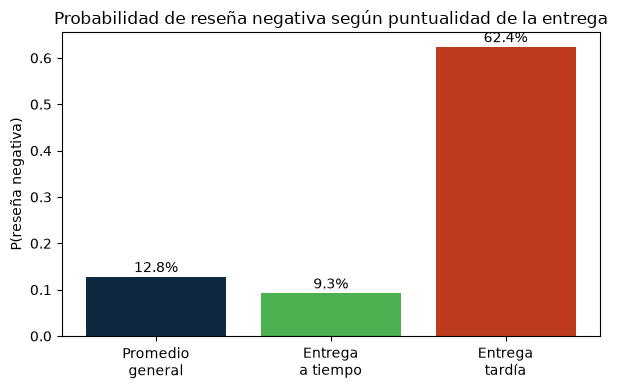

In [15]:
# ============================================================
# PASO 1: Preparar los datos para graficar
# ============================================================
categorias = ['Promedio\ngeneral', 'Entrega\na tiempo', 'Entrega\ntardía']
valores = [p_negativa_overall, p_negativa_dado_atiempo, p_negativa_dado_tardio]

# ============================================================
# PASO 2: Graficar barras
# ============================================================
fig = plt.figure(figsize=(6.2, 4))
plt.bar(categorias, valores, color=["#0E2841", "#4CAF50", "#BC3A1D"])

# ============================================================
# PASO 3: Escribir el porcentaje exacto encima de cada barra
# ============================================================
for i, v in enumerate(valores):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.ylabel("P(reseña negativa)")
plt.title("Probabilidad de reseña negativa según puntualidad de la entrega")
plt.tight_layout()
plt.show()

**Resultado:** una entrega tardía multiplica por **4.87x** la probabilidad 
de reseña negativa (62.4% vs. 12.8% general).

**Interpretación :** la puntualidad de entrega es, con amplio 
margen, el factor individual más asociado a la insatisfacción del cliente 
en Olist. Cualquier inversión en logística que reduzca el porcentaje de 
entregas tardías (actualmente 6.77% del total) tendría un impacto 
desproporcionadamente alto en la experiencia del cliente — más de la 
mitad de esos pedidos termina en reseña negativa.

# 2. Teorema de Bayes

**Pregunta de negocio:** dado que un pedido recibió una reseña negativa, 
¿qué tan probable es que haya llegado tarde? Esto es distinto a lo que 
calculamos en la Sección 1 — ahí sabíamos si el pedido llegó tarde y 
preguntábamos por la reseña; ahora partimos de la reseña (que ya 
conocemos apenas el cliente califica) y queremos inferir algo sobre la 
entrega.

$$P(\text{tardío} \mid \text{negativa}) = \frac{P(\text{negativa} \mid 
\text{tardío}) \cdot P(\text{tardío})}{P(\text{negativa})}$$

In [ ]:
# ============================================================
# PASO 1: Calcular las tres piezas que pide el Teorema de Bayes
# ============================================================
# P(evidencia | hipótesis): de los pedidos con reseña NEGATIVA, ¿qué
# proporción llegó tarde? Ya la teníamos calculada de forma inversa en
# la Sección 1 (p_negativa_dado_tardio), pero aquí necesitamos el
# "sentido contrario" -- lo calculamos directo:
p_tardio_given_negativa_directo = df_reviewed.loc[
    df_reviewed['resena_negativa'] == True, 'entrega_tardia'
].mean()

# El prior es la probabilidad de entrega tardía ANTES de conocer la reseña
p_tardio_prior = df_reviewed['entrega_tardia'].mean()

# P(evidencia): qué proporción de TODOS los pedidos tiene reseña negativa
p_negativa = df_reviewed['resena_negativa'].mean()

# P(negativa | tardío): ya la calculamos en la Sección 1
p_negativa_given_tardio = p_negativa_dado_tardio

# ============================================================
# PASO 2: Aplicar la fórmula de Bayes
# P(tardío|negativa) = P(negativa|tardío) * P(tardío) / P(negativa)
# ============================================================
p_tardio_given_negativa_bayes = (
    p_negativa_given_tardio * p_tardio_prior
) / p_negativa

# ============================================================
# PASO 3: Verificar contra el conteo directo (deben coincidir)
# ============================================================
print(f"Prior P(entrega tardía) = {p_tardio_prior:.4f}")
print(f"P(reseña negativa | tardío) = {p_negativa_given_tardio:.4f}")
print(f"P(reseña negativa) = {p_negativa:.4f}")
print(f"Posterior por Bayes: P(tardío | reseña negativa) = {p_tardio_given_negativa_bayes:.4f}")
print(f"Verificación directa (conteo): {p_tardio_given_negativa_directo:.4f}")

Prior P(entrega tardía) = 0.0666
P(reseña negativa | tardío) = 0.6240
P(reseña negativa) = 0.1281
Posterior por Bayes: P(tardío | reseña negativa) = 0.3245
Verificación directa (conteo): 0.3245


**Resultado:** P(entrega tardía | reseña negativa) = **32.45%** — casi 
5 veces el prior de 6.66%. Verificado con conteo directo (coincide 
exactamente: 0.3245).

**Interpretación de negocio:** invertir la probabilidad da a Olist una 
herramienta de diagnóstico retrospectivo: al ver una reseña negativa 
entrante, hay 1 en 3 probabilidades de que la causa raíz haya sido un 
retraso logístico. Esto permite priorizar investigaciones y distinguir 
entre reseñas negativas atribuibles a logística (32%) vs. otras causas 
como calidad de producto o servicio del vendedor (68% restante).